In [51]:
import wandb
from wandb.apis.public.runs import Run
import math
from typing import Any
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
api = wandb.Api()

In [8]:
runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "sweep-21-11-25", "state": "finished"},
)

In [64]:
# NOTE: All runs use INT3 element dtype
def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["block_size"] = run.config["quantisation"]["fmt"]["block_shape"][1]
    d["n_steps"] = run.config["training"]["n_steps"]
    d["lr_exponent"] = math.log2(run.config["training"]["optimiser"]["lr"])
    d["vqa"] = run.summary["downstream.vqa.accuracy"]
    d["vqa_easy"] = run.summary["downstream.vqa.accuracy_easy"]
    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [65]:
df = pd.DataFrame([cleanup_run(run) for run in runs])

In [66]:
df.sort_values(by=["lr_exponent", "block_size", "n_steps"], ascending=True, inplace=True)

In [67]:
df

,block_size,n_steps,lr_exponent,vqa,vqa_easy,train_loss,val_loss
13,32,0,-21.0,0.402018,0.686198,NaN,NaN
22,64,0,-21.0,0.413411,0.679688,NaN,NaN
4,64,8192,-21.0,0.566081,0.765299,0.041101,0.591052
17,128,0,-21.0,0.282227,0.490234,NaN,NaN
3,128,8192,-21.0,0.470378,0.744141,0.049955,0.703892
5,32,0,-20.0,0.402018,0.686198,NaN,NaN
15,64,0,-20.0,0.413411,0.679688,NaN,NaN
12,64,8192,-20.0,0.538737,0.773763,0.034114,0.580256
2,128,0,-20.0,0.282227,0.490234,NaN,NaN
20,128,8192,-20.0,0.480469,0.746745,0.041301,0.646556


In [35]:
# Only runs after training
df_t = df[df["n_steps"] != 0]

## Does validation loss correlate with VQA accuracy?

<Axes: xlabel='val_loss', ylabel='vqa_easy'>

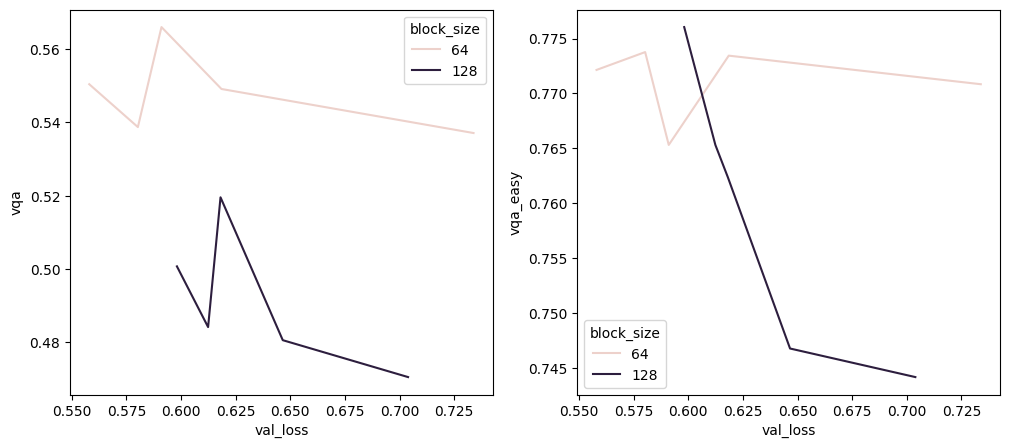

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(df_t, x="val_loss", y="vqa", hue="block_size", ax=axes[0])
sns.lineplot(df_t, x="val_loss", y="vqa_easy", hue="block_size", ax=axes[1])

## What is the best learning rate?

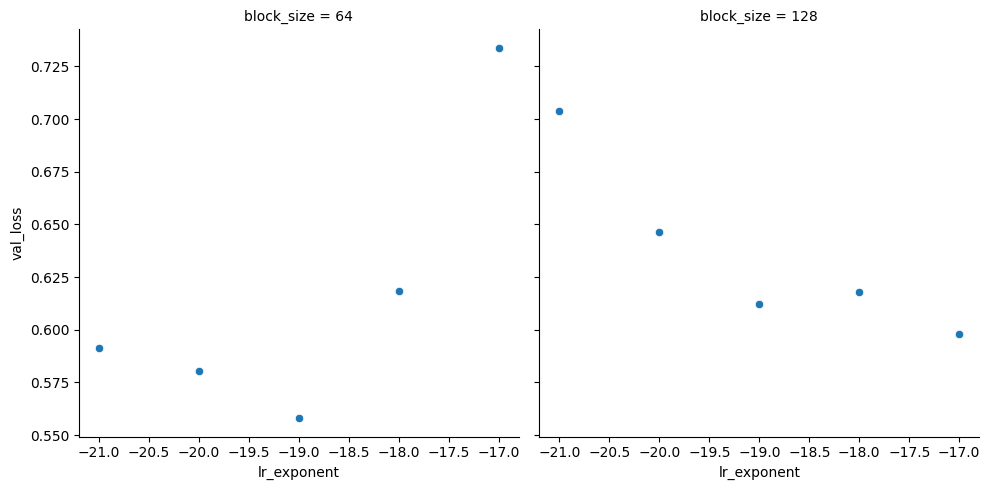

In [55]:
sns.relplot(df[df["n_steps"] != 0], x="lr_exponent", y="val_loss", col="block_size")

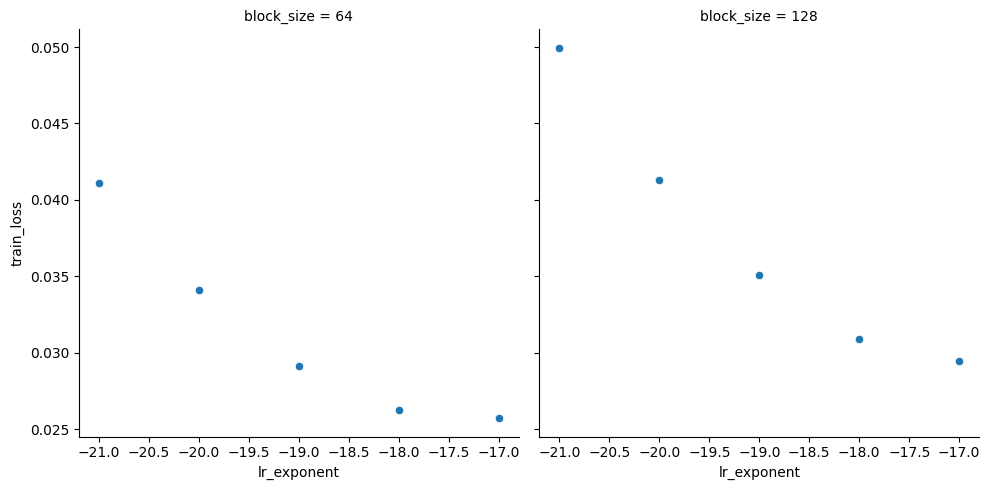

In [54]:
sns.relplot(df[df["n_steps"] != 0], x="lr_exponent", y="train_loss", col="block_size")

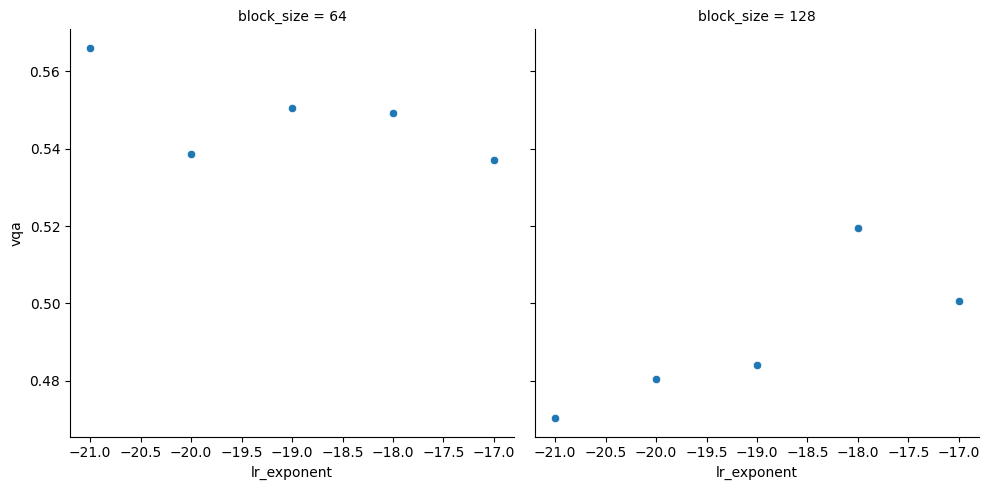

In [59]:
sns.relplot(df[df["n_steps"] != 0], x="lr_exponent", y="vqa", col="block_size")